In [31]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

In [32]:
# memory
taco_dense_mem = pd.read_csv("./results/taco_dense_mem.csv")
taco_dense_parallel_mem = pd.read_csv("./results/taco_dense_mem.csv")
taco_sparse_mem = pd.read_csv("./results/taco_csr_mem.csv")
taco_sparse_opt_mem = pd.read_csv("./results/taco_csr_mem.csv")
bitmap_mem = pd.read_csv("./results/bitmap_mem.csv")
bitmap_parallel_mem = pd.read_csv("./results/bitmap_parallel_mem.csv")
# runtime
taco_dense_run = pd.read_csv("./results/taco_dense_run.csv")
taco_dense_parallel_run = pd.read_csv("./results/taco_dense_parallel_run.csv")
taco_sparse_run = pd.read_csv("./results/taco_csr_seq_run.csv")
taco_sparse_opt_run = pd.read_csv("./results/taco_csr_opt_run.csv")
bitmap_run = pd.read_csv("./results/bitmap_run.csv")
bitmap_parallel_run = pd.read_csv("./results/bitmap_parallel_run.csv")

In [33]:
%%capture
%run ./runtime.ipynb
%run ./mem.ipynb

In [34]:
mem_frames = [
    format_mem(taco_dense_mem, "dense"),
    format_mem(taco_dense_parallel_mem, "dense_parallel"),
    format_mem(taco_sparse_mem, "sparse"),
    format_mem(taco_sparse_opt_mem, "human_expert"),
    format_mem(bitmap_mem, "bitmap"),
    format_mem(bitmap_parallel_mem, "bitmap_parallel"),
]

In [35]:
run_frames = [
    format_runtime(taco_dense_run, "dense"),
    format_runtime(taco_dense_parallel_run, "dense_parallel"),
    format_runtime(taco_sparse_run, "sparse"),
    format_runtime(taco_sparse_opt_run, "human_expert"),
    format_runtime(bitmap_run, "bitmap"),
    format_runtime(bitmap_parallel_run, "bitmap_parallel"),
]

In [36]:
mem_df = pd.concat(mem_frames)
run_df = pd.concat(run_frames)

In [37]:
run_df = run_df.groupby(['kernel', 'sparsity', 'M', 'K'], as_index=False)['seconds'].mean()

In [38]:
merged = pd.merge(run_df, mem_df[['kernel', 'M', 'K', 'sparsity', 'file', 'mb']], on=['kernel', 'M', 'K', 'sparsity'], how='left')
full_df = merged[['M', 'K', 'seconds', 'kernel', 'sparsity', 'mb']]
full_df = full_df.sort_values(by=['M', 'sparsity'])

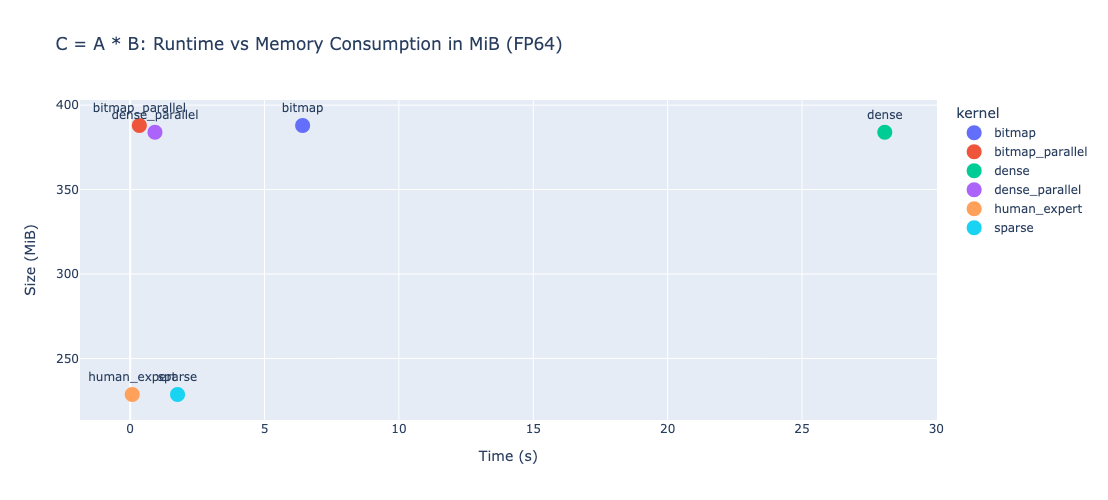

In [39]:
single_df = full_df[(full_df["M"] == 4096) & (full_df["sparsity"] == 90)]
fig = px.scatter(single_df,
      x='seconds', 
      y='mb',
      hover_data=["seconds", "mb"],
      color='kernel',
      text='kernel',
      title='C = A * B: Runtime vs Memory Consumption in MiB (FP64)',
      labels={'seconds': 'Time (s)', 'mb': 'Size (MiB)'},
      width=1000, height=500,
)
fig.update_traces(marker_size=15, textposition='top center')
fig.show()

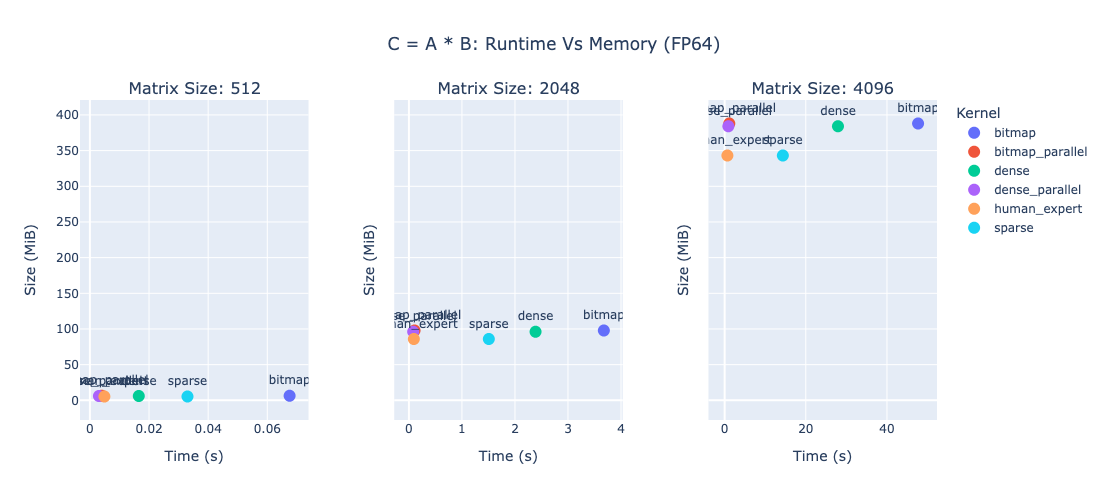

In [40]:
SIZES = [512, 2048, 4096]
SPARSITY = 50

fig = make_subplots(
    rows=1, 
    cols=3,
    subplot_titles=(f'Matrix Size: {SIZES[0]}',
                   f'Matrix Size: {SIZES[1]}',
                   f'Matrix Size: {SIZES[2]}',),
    horizontal_spacing=0.1,
    shared_yaxes=True,
    shared_xaxes=False
)


df_list = []
for size in SIZES:
    df_list.append(full_df[(full_df["M"] == size) & (full_df["sparsity"] == SPARSITY)])

unique_kernels = full_df['kernel'].unique()
color_sequence = px.colors.qualitative.Plotly

for i, df in enumerate(df_list, start=1):
    for j, kernel in enumerate(unique_kernels):
        kernel_df = df[df['kernel'] == kernel]
        fig.add_trace(
            go.Scatter(
                x=kernel_df['seconds'],
                y=kernel_df['mb'],
                mode='markers+text',
                name=kernel,
                text=kernel,
                textposition='top center',
                marker=dict(
                    size=15,
                    color=color_sequence[j % len(color_sequence)]
                ),
                hovertemplate=(
                    "Time: %{x:.2f}s<br>" +
                    "Memory: %{y:.2f} MiB<br>" +
                    "<extra></extra>"
                ),
                showlegend=True if i == 1 else False,
            ),
            row=1, col=i
        )

fig.update_layout(
    title_text="C = A * B: Runtime Vs Memory (FP64)",
    title_x=0.5,
    height=500,
    width=1600,
    legend_title_text='Kernel',
    hovermode='closest'
)

fig.update_xaxes(title_text="Time (s)", row=1, col=1)
fig.update_xaxes(title_text="Time (s)", row=1, col=2)
fig.update_xaxes(title_text="Time (s)", row=1, col=3)
fig.update_yaxes(title_text="Size (MiB)", row=1, col=1)
fig.update_yaxes(title_text="Size (MiB)", row=1, col=2)
fig.update_yaxes(title_text="Size (MiB)", row=1, col=3)

fig.update_traces(marker=dict(size=12), textposition='top center')

fig.show()